<a href="https://colab.research.google.com/github/ablamitovroman/data-analysis-practice/blob/main/Sales_Merge_%26_Analytics_Pipeline_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aufgabe

Stark! Genau das ist der beste Weg, um echten Code-Speicher aufzubauen. Keine Hilfestellungen, kein fertiger Code.

Hier ist deine neue Aufgabenstellung:

---

### Rohdaten

Erstelle dir zuerst zwei kleine Datensätze (z. B. als Python-Dictionaries oder erstelle die Dateien direkt in Colab):

**Datei 1: `kunden.csv**`

```text
Kunden_ID,Name,Region
101,Mueller,Nord
102,Schmidt,Sued
103,Weber,Nord
104,Wagner,West

```

**Datei 2: `bestellungen.xlsx**`

```text
Bestell_ID,Kunden_ID,Produkt,Betrag
1,101,Laptop,1200.0
2,102,Smartphone,800.0
3,101,Maus,25.0
4,103,Tastatur,60.0
5,105,Monitor,250.0

```

---

### Deine Aufgaben

Schreibe eine eigene Python-Logik (gerne als Klasse oder mit sauberen Funktionen), die Folgendes ausführt:

1. **Dateien einlesen:** Lade beide Dateien (`kunden.csv` und `bestellungen.xlsx`) in Pandas DataFrames.
2. **Daten zusammenführen (Merge):** Verbinde die Bestellungen mit den Kundendaten über die `Kunden_ID`.
* *Achtung:* Es sollen **nur** die Bestellungen im Ergebnis sein, bei denen der Kunde auch in `kunden.csv` existiert (Kunde 105 soll also herausgefiltert werden).


3. **Analyse pro Region:** Erstelle eine Auswertung, die für jede **Region** Folgendes berechnet:
* `Gesamtumsatz` (Summe aller Beträge)
* `Anzahl_Bestellungen` (Anzahl der Käufe)
* `Durchschnitt_Umsatz` (Mittelwert pro Kauf)


4. **Sortierung:** Sortiere das Ergebnis nach `Gesamtumsatz` absteigend.
5. **Export:** Speichere das finale Analyse-Ergebnis als Excel-Datei unter dem Namen `regional_analyse.xlsx`.

---

Leg los und tippe den Code komplett selbst ein. Wenn du fertig bist oder an einer Stelle nicht weiterkommst, poste deinen Code hier!

#1. Erstellen von Dateien aus Rohdatten

In [1]:
import io
import pandas as pd

kunden = """Kunden_ID,Name,Region
101,Mueller,Nord
102,Schmidt,Sued
103,Weber,Nord
104,Wagner,West"""

bestellungen = """Bestell_ID,Kunden_ID,Produkt,Betrag
1,101,Laptop,1200.0
2,102,Smartphone,800.0
3,101,Maus,25.0
4,103,Tastatur,60.0
5,105,Monitor,250.0"""

df_kunden = pd.read_csv(io.StringIO(kunden))
df_kunden.to_csv("kunden.csv", index=False)

df_bestellungen = pd.read_csv(io.StringIO(bestellungen))
df_bestellungen.to_excel("bestellungen.xlsx", index=False)

# 2. Загрузка данных и объединение (Merge)

In [2]:
import pandas as pd

try:
    df_gesamt = (
        pd.read_excel("bestellungen.xlsx")
        .merge(pd.read_csv("kunden.csv"),
               on="Kunden_ID",
               how="left")
        .fillna({
            "Name": "Unbekannter Kunde",
            "Region": "Kein Region"
        })
    )
    print("--- Успешно загружено и объединено: ---")
    print(df_gesamt)

except FileNotFoundError as e:
    print(f"Ошибка: Файл не найден! Детали: {e}")
except KeyError as e:
    print(f"Ошибка: В одном из файлов отсутствует ключевой столбец! Детали: {e}")
except Exception as e:
    print(f"Произошла непредвиденная ошибка: {e}")

--- Успешно загружено и объединено: ---
   Bestell_ID  Kunden_ID     Produkt  Betrag               Name       Region
0           1        101      Laptop    1200            Mueller         Nord
1           2        102  Smartphone     800            Schmidt         Sued
2           3        101        Maus      25            Mueller         Nord
3           4        103    Tastatur      60              Weber         Nord
4           5        105     Monitor     250  Unbekannter Kunde  Kein Region


#3. Analyse pro Region

In [3]:
try:
  if not df_gesamt.empty:
    region_analyse = (
      df_gesamt
        .groupby("Region", as_index=False)
        .agg(
            Gesamtumsatz = ("Betrag", "sum"),
            Anzahl_bestellungen = ("Bestell_ID", "count"),
            Durchschnitt_preis = ("Betrag", lambda x: round(x.mean(), 2))
          )
        .sort_values(by="Gesamtumsatz", ascending=False)
    )
    print(region_analyse)
    region_analyse.to_csv("Region_Analyse.csv", index=False)
  else:
    print("Tabelle ist leer")
except NameError:
    print("Fehler: 'df_gesamt' ist nicht definiert.")
except KeyError as e:
    print(f"Fehler: Spalte fehlt in den Daten: {e}")
except Exception as e:
    print(f"Unerwarteter Fehler: {e}")

        Region  Gesamtumsatz  Anzahl_bestellungen  Durchschnitt_preis
1         Nord          1285                    3              428.33
2         Sued           800                    1              800.00
0  Kein Region           250                    1              250.00


#Visualisieren

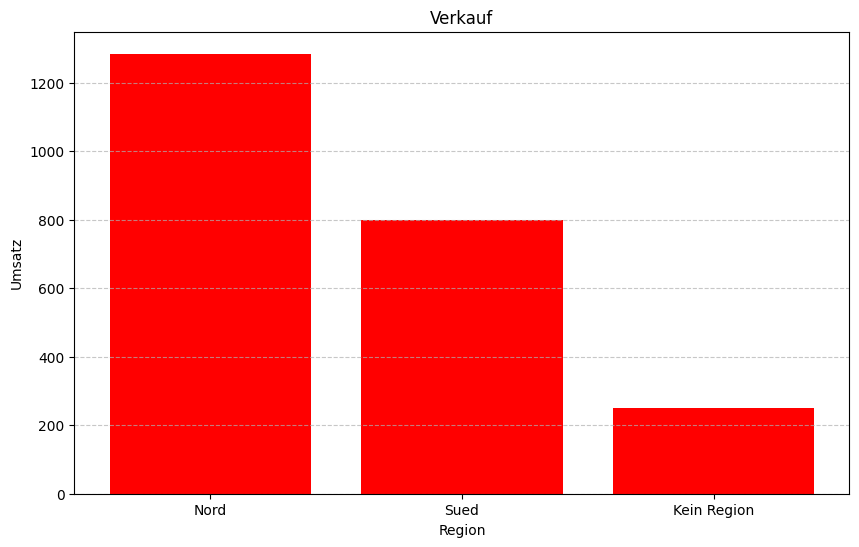

In [8]:
import matplotlib.pyplot as plt

try:
  plt.figure(figsize=(10,6))
  plt.bar(region_analyse["Region"], region_analyse["Gesamtumsatz"], color="red")
  plt.title("Verkauf")
  plt.xlabel("Region")
  plt.ylabel("Umsatz")
  plt.grid(axis="y", linestyle="--", alpha=0.7)

  plt.savefig("Verkauf.png", dpi=300)
  plt.show()
except Exception as er:
  print(f"Graifk könnte nicht erstellt werden {er}")